1) Download the dataset and take a look at it

In [10]:
import pandas as pd
import numpy as np

df = pd.read_csv("./creditcard.csv")
df.head(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [11]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [12]:
print(df.isna().sum().sum(), df.isnull().sum().max())

0 0


Note: no null and no NaN values!

Let's now see how balanced/imbalanced the dataset is:

In [13]:
percentages = df["Class"].value_counts(normalize=True) * 100

print(f"No fraud: {percentages[0]:.2f}%, Fraud: {percentages[1]:.2f}%")

No fraud: 99.83%, Fraud: 0.17%


Obviously, the dataset is imbalanced. There are plenty of methods to solve this problem. For classic algorithms, I'll use balanced learning. I will also elaborate on method for nn later

Now to the models: I will first implement classic ML algorithms like Logistic Regression, Random Forest, and KNN. Let's evaluate them with cross-validation and choose the best. Afterwards, I'll build an Neural Network with Tensorflow. 

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

classifiers = {
    "LogReg": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "KNN": KNeighborsClassifier(weights='distance'),
    "RandomForest": RandomForestClassifier(class_weight='balanced')
}    

In [15]:
from sklearn.model_selection import train_test_split

X, y = df.drop(columns=['Class']), df['Class'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

Also note that we need to scale Amount and Time

In [18]:
from sklearn.model_selection import cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ('scaler', StandardScaler(), ['Amount', 'Time'])
    ],
    remainder='passthrough'
)

for name, classifier in classifiers.items():
    pipeline = make_pipeline(preprocessor, classifier)
    
    cv_scores = cross_val_score(
        pipeline, X_train, y_train, cv=5, scoring='average_precision'    
    )
    print(f"{name} has {cv_scores.mean() * 100:.2f}% training AUPRC score")

LogReg has 75.28% training AUPRC score
KNN has 80.41% training AUPRC score
RandomForest has 84.37% training AUPRC score


Random Forest showed the best score, so we will proceed with this algorithm. Going further, we can start Hyperparametr Tuning to reach the best version of Random Forest.

In [22]:
from sklearn.model_selection import RandomizedSearchCV

base_rf = RandomForestClassifier(class_weight='balanced', random_state=42)
pipeline = make_pipeline(preprocessor, base_rf)

param_grid = {
    'randomforestclassifier__n_estimators': [100, 150, 200],
    'randomforestclassifier__max_depth': [10, 15, None],
    'randomforestclassifier__min_samples_split': [2, 5, 10],
    'randomforestclassifier__min_samples_leaf': [1, 2, 5],
    'randomforestclassifier__max_features': ['sqrt', 'log2']
}

random_search = RandomizedSearchCV(
    estimator=pipeline, 
    param_distributions=param_grid, 
    n_iter=15,                 
    cv=5,                      
    scoring='average_precision', 
    n_jobs=-1,                 
    random_state=42,
    verbose=2
)

random_search.fit(X_train, y_train)

print(f"Best AUPRC score: {random_search.best_score_ * 100:.2f}%")
print("Best params", random_search.best_params_)

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best AUPRC score: 84.50%
Best params {'randomforestclassifier__n_estimators': 150, 'randomforestclassifier__min_samples_split': 2, 'randomforestclassifier__min_samples_leaf': 1, 'randomforestclassifier__max_features': 'sqrt', 'randomforestclassifier__max_depth': None}


We did not get much more, but 84.5% is still an upgrade. Now let's see how our algorithms performs on test data

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.81      0.87        98

    accuracy                           1.00     56962
   macro avg       0.97      0.90      0.93     56962
weighted avg       1.00      1.00      1.00     56962

Confusion matrix:
TN: 56859, FP: 5
FN: 19, TP: 79
Precision-Recall:


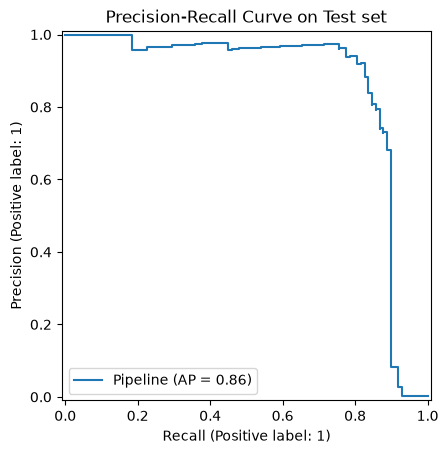

In [23]:
from sklearn.metrics import classification_report, confusion_matrix, PrecisionRecallDisplay
import matplotlib.pyplot as plt

best_pipeline = random_search.best_estimator_

y_pred = best_pipeline.predict(X_test)
y_scores = best_pipeline.predict_proba(X_test)[:, 1]

print("Classification report:")
print(classification_report(y_test, y_pred))

print("Confusion matrix:")
cm = confusion_matrix(y_test, y_pred)
print(f"TN: {cm[0][0]}, FP: {cm[0][1]}")
print(f"FN: {cm[1][0]}, TP: {cm[1][1]}")

print("Precision-Recall:")
PrecisionRecallDisplay.from_estimator(best_pipeline, X_test, y_test)
plt.title("Precision-Recall Curve on Test set")
plt.show()

Great! We've achieved **81% recall and 94% Precision** on the fraud transactions

Let's now try the neural network:

In [24]:
import tensorflow as tf

In [26]:
X = df.drop(columns=['Class'])
y = df['Class'].copy()

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, 
    random_state=42, stratify=y_train_full
)

preprocessor = ColumnTransformer(
    transformers=[('scaler', StandardScaler(), ['Amount', 'Time'])],
    remainder='passthrough'
)

X_train_scaled = preprocessor.fit_transform(X_train)
X_val_scaled = preprocessor.transform(X_val)
X_test_scaled = preprocessor.transform(X_test)

print(f"train: {X_train_scaled.shape}, val: {X_val_scaled.shape}, test: {X_test_scaled.shape}")

train: (182276, 30), val: (45569, 30), test: (56962, 30)


To overcome the imbalanced dataset issue, I'll use initial bias for the nn, with special weights for both classes.

In [38]:
neg, pos = np.bincount(y_train)
initial_bias = np.log(pos / neg)

total = neg + pos
weight_for_0 = 1.0
weight_for_1 = np.sqrt(neg / pos)
class_weight = {0: weight_for_0, 1: weight_for_1}

print(f"Initial bias: {initial_bias:.4f}")
print(f"Weights, 0: {weight_for_0:.2f}  1: {weight_for_1:.2f}")

Initial bias: -6.3590
Weights, 0: 1.00  1: 24.03


In [39]:
def create_model(input_dim, output_bias):
    bias_initializer = tf.keras.initializers.Constant(output_bias)
    
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)),
        
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.3),

        tf.keras.layers.Dense(16, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.3),
        
        tf.keras.layers.Dense(1, activation='sigmoid', bias_initializer=bias_initializer),
    ])
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss=tf.keras.losses.BinaryCrossentropy(),
        metrics=[
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall'),
            tf.keras.metrics.AUC(name='pr_auc', curve='PR') 
        ]
    )
    return model

model = create_model(input_dim=X_train_scaled.shape[1], output_bias=initial_bias)
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                      │ (None, 32)                  │             992 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 16)                  │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,729 (6.75 KB)

 Trainable params: 1,633 (6.38 KB)

 Non-trainable params: 96 (384.00 B)

In [40]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_pr_auc',
    verbose=1,
    patience=5,
    mode='max',
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled,
    y_train,
    batch_size=2048,
    epochs=50,
    validation_data=(X_val_scaled, y_val),
    class_weight=class_weight,
    callbacks=[early_stopping]
)

Epoch 1/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1739 - pr_auc: 0.1701 - precision: 0.2134 - recall: 0.3651 - val_loss: 0.0080 - val_pr_auc: 0.4571 - val_precision: 0.8182 - val_recall: 0.2278
Epoch 2/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1406 - pr_auc: 0.2683 - precision: 0.2492 - recall: 0.4698 - val_loss: 0.0071 - val_pr_auc: 0.5436 - val_precision: 0.8000 - val_recall: 0.4557
Epoch 3/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1223 - pr_auc: 0.3375 - precision: 0.2828 - recall: 0.5333 - val_loss: 0.0072 - val_pr_auc: 0.6030 - val_precision: 0.7500 - val_recall: 0.5696
Epoch 4/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1012 - pr_auc: 0.3821 - precision: 0.2984 - recall: 0.5873 - val_loss: 0.0074 - val_pr_auc: 0.6366 - val_precision: 0.7538 - val_recall: 0.6203
Epoch 5/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0944 - pr_auc: 0.4066 - precision: 0.3299 - recall: 0.6127 - val_loss: 0.0077 - val_pr_auc: 0.6591 - val_precision: 0.7846 -

In [42]:
y_probabilities = model.predict(X_test_scaled).flatten()

y_pred = (y_probabilities >= 0.5).astype(int)

print("NN report: ")
print(classification_report(y_test, y_pred))

print("Confusion Matrix")
cm = confusion_matrix(y_test, y_pred)
print(f"TN: {cm[0][0]}, FP: {cm[0][1]}")
print(f"FN: {cm[1][0]}, TP: {cm[1][1]}")

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 1s 420us/step
NN report: 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.71      0.84      0.77        98

    accuracy                           1.00     56962
   macro avg       0.85      0.92      0.88     56962
weighted avg       1.00      1.00      1.00     56962

Confusion Matrix
TN: 56830, FP: 34
FN: 16, TP: 82


**SUMMARY**:
We can see that NN's Recall is bigger as it caught more fraud operations. But, at the same time, it marked a lot of non-fraud operations as fraud ones which leads to poor Precision.

So, Random Forest has better precision (**94%** against **71%**), and NN has better Recall (**84%** against **81%**).

Depending on the buiseness goal of the company, either of these models could be preferable. But in the most of the real-life cases the company would choose Random Forest over NN in this situation, as Precision is much more important than Recall in Fraud detection tasks.